In [1]:
!TZ=America/Chicago date

Tue Feb 18 19:21:43 CST 2020


# Introduction

This Jupyter notebook, with code written in Python, contains the calculations of all results presented in Section 3 of the article. First we compare results for correct and incorrect implementations of the finite-population model. Then we turn to the infinite-population model.

In [2]:
%matplotlib notebook
"""
Load the code base.
"""
%run    ./Code/bs.py
%run -i ./Code/rates.py
%run -i ./Code/derivative.py
%run -i ./Code/solver.py
%run -i ./Code/binned_mixture.py
%run -i ./Code/equilibria.py
"""
Suppress automatic display of graphics generated by Matplotlib. All
graphics are saved to disk, and are displayed by explicit commands.
"""
plt.interactive(False)
"""
Define the name of the subdirectory that holds various files associated
with this notebook, and create the directory if it does not exist already.
"""
DIR = './SM1data/'
!if [ ! -d {DIR} ]; then mkdir {DIR}; fi

# The finite-population model

## Modification of the Euler forward method

According to Basener and Sanford (Section 5), the derivative of a class frequency $P_i(t)$ is undefined when the corresponding relative frequency $P_i(t) / \sum_j P_j(t)$ is less than the threshold of $10^{-9}.$ A frequency $P_i(t)$ with an undefined derivative is set to zero. The authors fail to observe that frequencies of zero must remain zero forever because their derivatives are undefined.

More &hellip;

In [ ]:
# %load './Code/modified_euler.py'
class ModifiedEuler(object):
    """
    Modification of Euler forward method for numerical integration.
    
    EXPAND:
    1. Euler forward method is applied when `threshold` is zero.
    2. Callable and indexable.
    3. Customized to application. It is assumed that subthreshold
    frequencies are at the tails of the frequency distribution.
    """
    def __init__(self, derivative, initial_freqs, threshold=0):
        """
        NEED
        """
        self.derivative = derivative
        self.threshold = threshold
        #
        # Array `s` always contains the current solution. The base type
        # of `s` is the base type of `initial_value`. Subthreshold
        # frequencies are zeroed.
        self.s = initial_freqs + 0
        self.s[self.s < threshold * np.sum(self.s)] = 0
        #
        # Slice `support` indicates which classes have positive
        # frequencies, i.e., which classes to include in the calculation
        # of derivatives.
        self.support = slice_to_support(self.s)
        #
        # Array `solutions` contains the end-of-year solutions. The base
        # type is float.
        self.solutions = np.empty((1, len(self.s)), dtype=float)
        self.solutions[0] = self.s
        self.n_solutions = 1
        
    def __call__(self, n_years, steps_per_year):
        """
        NEED
        
        There are `steps_per_year` numerical integration steps per year.
        At the end of each year, the current solution is stored.
        """
        self._extend_storage(n_years)
        step_size = 1 / steps_per_year
        for _ in range(n_years):
            for _ in range(steps_per_year):
                self.integration_step(step_size)
            self.scale_current_solution()
            self.solutions[self.n_solutions] = self.s
            self.n_solutions += 1

    def integration_step(self, step_size):
        """
        Performs an integration step; zeroes subthreshold frequencies.
        """
        # The derivative calculation is restricted to classes in the
        # support of the frequency distribution. 
        self.s += step_size * self.derivative(0, self.s, self.support)
        #
        # Zero frequencies that have fallen below threshold.
        included = self.s[self.support]
        included[included < self.threshold * fsum(included)] = 0
        #
        # Update the support if any frequencies of classes in the
        # support have been zeroed.
        if included[-1] == 0 or included[0] == 0:
            self.support = slice_to_support(self.s)
    
    def scale_current_solution(self):
        """
        Scales the current solution to avoid overflow and underflow.
        """
        # Make the maximum frequency of the solution have an exponent
        # of 768. Scaling a floating point number by an integer power
        # of 2 does not change its mantissa. Thus there is no loss in
        # precision.
        _, max_exponent = frexp(self.s.max())
        self.s *= 2.0 ** (768 - max_exponent)
        
    def __getitem__(self, which):
        """
        Returns the result of indexing solutions by `which`.
        
        The frequency vector for each year is normalized.
        """
        s = self.solutions[which]
        if s.ndim == 1:
            return s / fsum(s)
        return s / s.sum(axis=1)[:,None]

    def __len__(self):
        """
        Returns the number of stored solutions (one per year).
        """
        return len(self.solutions)

    def _extend_storage(self, n):
        rows, cols = self.solutions.shape
        new = np.zeros((rows+n, cols), dtype=float)
        new[:rows] = self.solutions
        self.solutions = new


class PoorlyModifiedEuler(ModifiedEuler):
    def integration_step(self, step_size):
        """
        Incorrectly performs an integration step.
        
        Derivatives should not be calculated for frequencies that are
        below threshold, but they are. All frequencies are updated, and
        only those that are below threshold after the update are zeroed.
        That is, previously zeroed frequencies are not held at zero.
        """
        self.s += step_size * self.derivative(0, self.s)
        self.s[self.s < self.threshold * fsum(self.s)] = 0

In [235]:
def run_finite(solver_class, n_years=2500, steps_per_year=1,
               threshold=1e-9, freq_type=float):
    max_birth_rate = mp_float('0.2')
    rates = Rates(max_birth_rate, death='0.1', bin_width='5e-4')
    p = binned_mixture(gamma_ccdf, len(rates.effects), '1e-3')
    derivative = Derivative(p, rates, basetype=float)
    initial_freqs = binned_normal(rates.fitness_walls, mean='0.044',
                                  std='0.005').astype(freq_type)
    solver = solver_class(derivative, initial_freqs, threshold)
    solver(n_years, steps_per_year)
    return solver, rates, derivative

In [236]:
%%time

s, rates, d = run_finite(ModifiedEuler, 10, steps_per_year=2**5)

CPU times: user 37.7 s, sys: 59.3 ms, total: 37.7 s
Wall time: 37.8 s


<IPython.core.display.Javascript object>


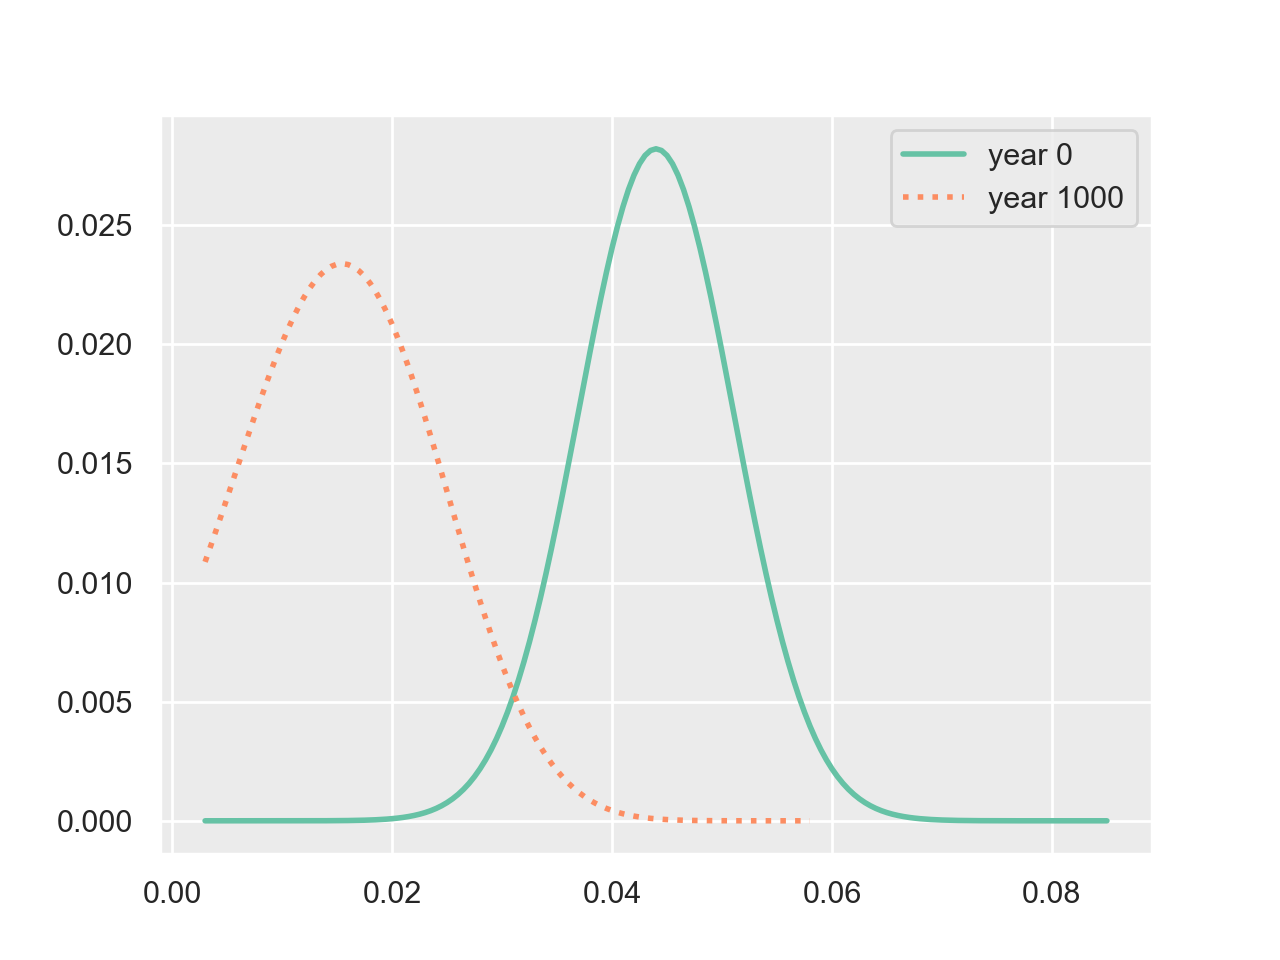

In [232]:
fig, ax = plt.subplots()
fit=rates.fitness
w = s[0] > 0
ax.plot(fit[w], s[0, w], label='year 0')
w = s[-1] > 0
ax.plot(fit[w], s[-1,w], label='year {}'.format(len(s)-1), ls=':')
ax.legend()

<IPython.core.display.Javascript object>


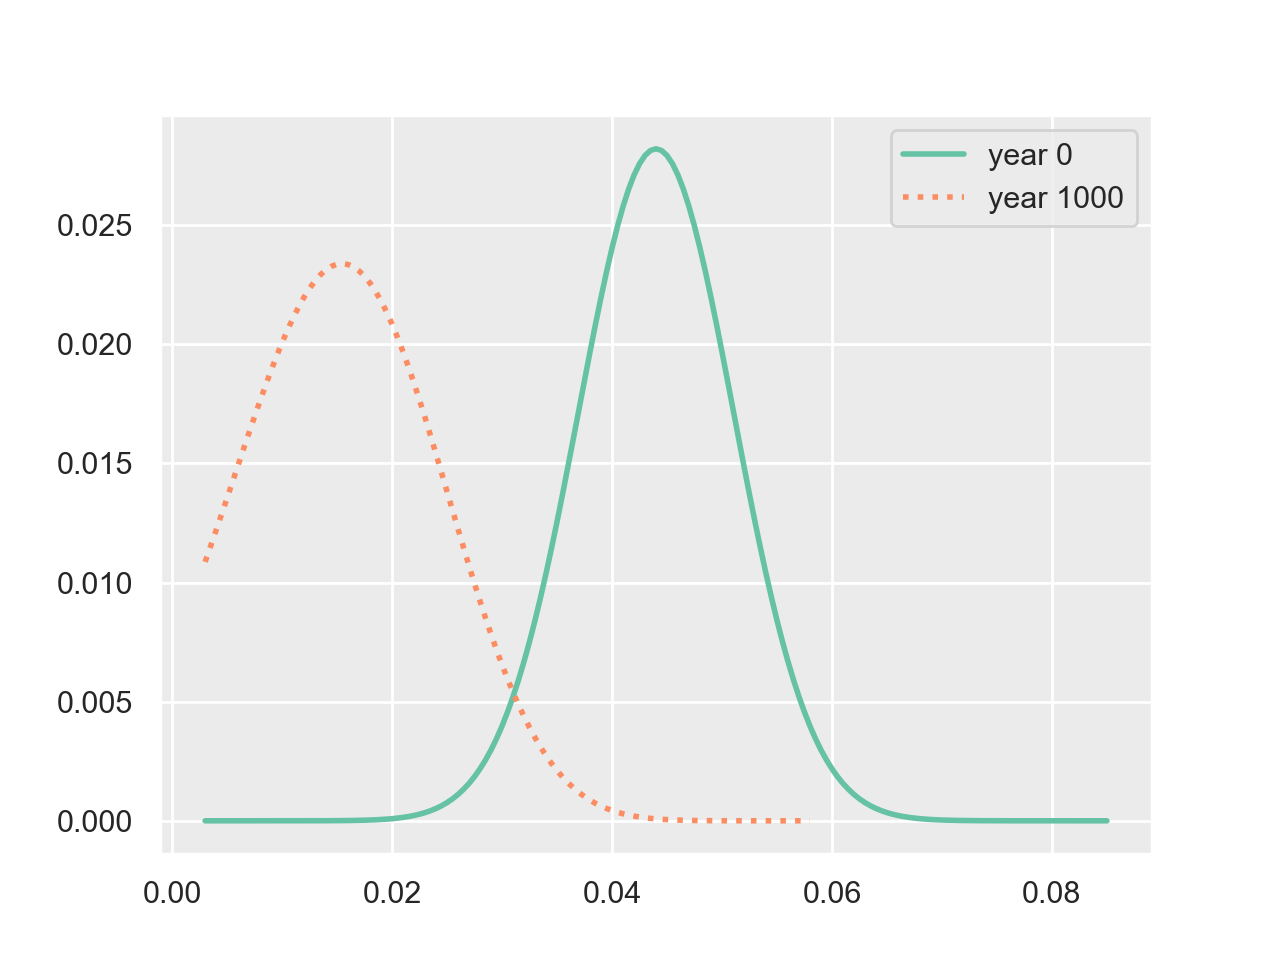

In [208]:
fig, ax = plt.subplots()
fit=rates.fitness
w = s[0] > 0
ax.plot(fit[w], s[0, w], label='year 0')
w = s[-1] > 0
ax.plot(fit[w], s[-1,w], label='year {}'.format(len(s)-1), ls=':')
ax.legend()


<IPython.core.display.Javascript object>


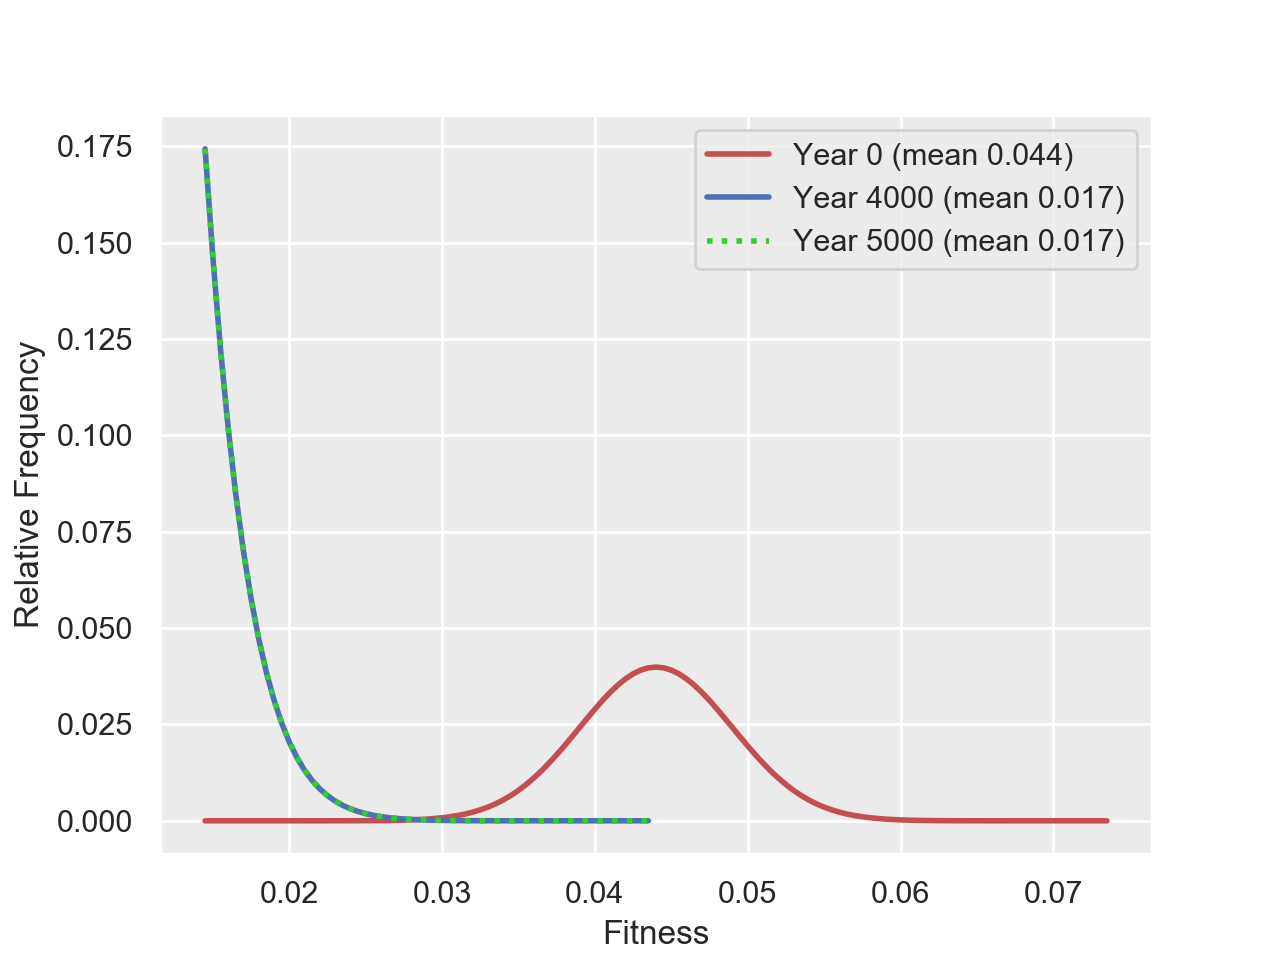

(<Figure size 640x480 with 1 Axes>,
 <matplotlib.axes._subplots.AxesSubplot at 0x1a3c1dc5c0>)

In [95]:
#s(2500, 2**5)
bs_plot(s, rates.fitness, 4000, ['-', '-', ':'])

In [78]:
%%time

bad_s, rates = run_finite(PoorlyModifiedEuler)

CPU times: user 1.73 s, sys: 89 ms, total: 1.82 s
Wall time: 632 ms


<IPython.core.display.Javascript object>


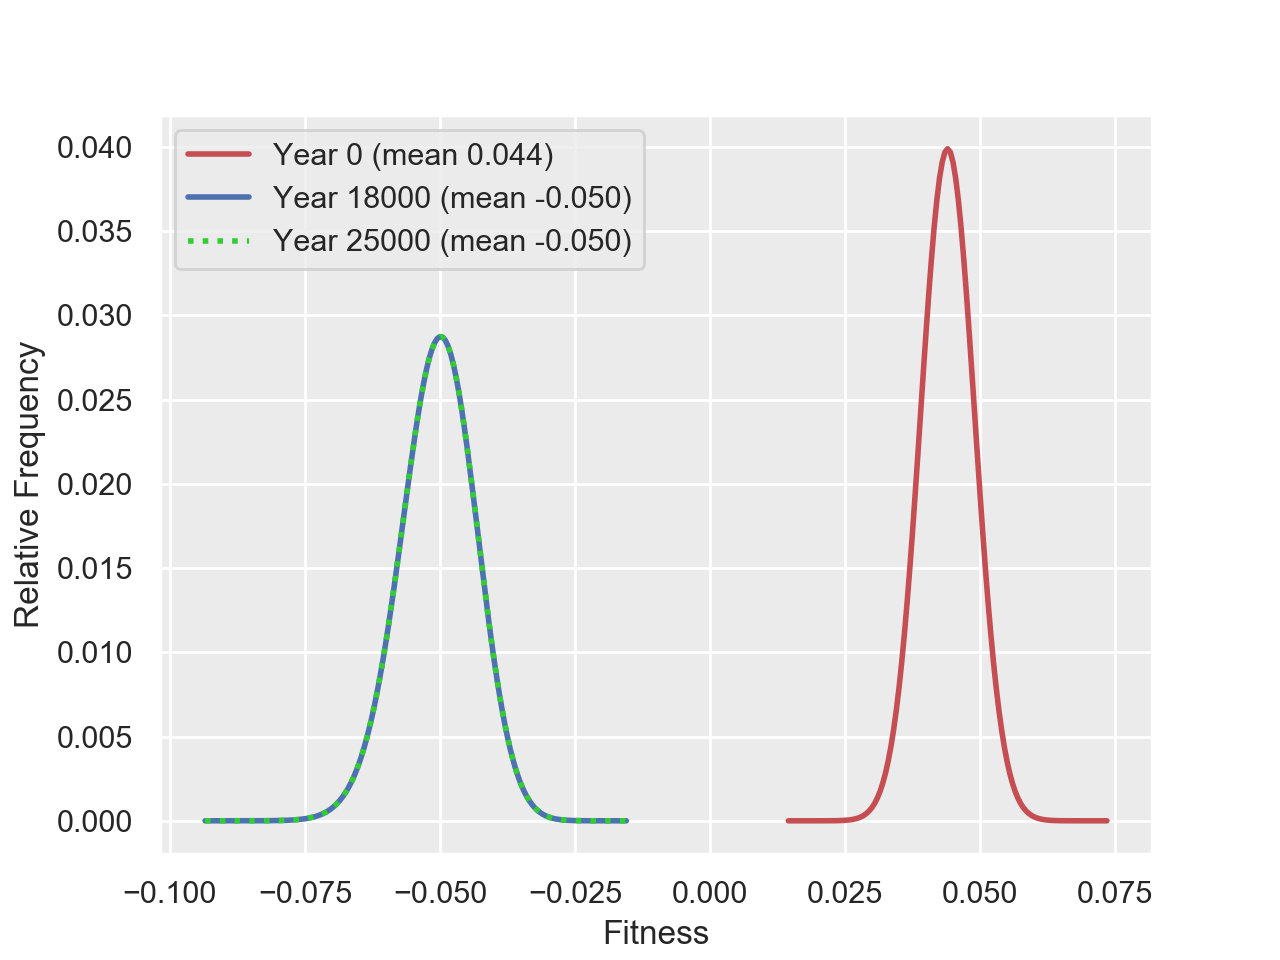

(<Figure size 640x480 with 1 Axes>,
 <matplotlib.axes._subplots.AxesSubplot at 0x1a3d67bb00>)

In [97]:
#bad_s(5000, 1)
bs_plot(bad_s, rates.fitness, 18000, ['-', '-', ':'])

## FTNSwM does not hold for finite-pop model

\begin{align}
    \frac{\text{d}\bar{m}}{\text{d}t}
       &= \text{Var}(m) + \frac{1}{\sum_i P_i} \sum_i
             \left(\left(\sum_j b_j f_{ij} P_j\right) - b_i P_i\right) (m_i - \bar{m}) \nonumber \\
       &= \text{Var}(m) + \frac{1}{\sum_i P_i} \sum_i
             \left(\frac{\text{d}P_i}{\text{d}t} - m_i P_i\right) (m_i - \bar{m}) 
    \label{eq:FTNSwM}
\end{align}

In [129]:
def theorem_value(frequencies, derivatives, fitnesses):
    norm = fsum(frequencies)
    mean, var = mean_var(frequencies, fitnesses)
    rate_differences = derivatives - fitnesses * frequencies
    fitness_deviates = fitnesses - mean
    return var + fsum(rate_differences * fitness_deviates) / norm

def check_theorem(frequencies, derivative, fitnesses, delta_t=2**-20,
                  threshold=2**-20):
    derivatives = derivative(None, frequencies)
    theorem = theorem_value(frequencies, derivatives, fitnesses)
    mean = mp_mean(frequencies, fitnesses)
    new_freqs = frequencies + time_step * derivatives
    new_freqs[new_freqs < threshold * fsum(new_freqs)] = 0
    new_mean = mp_mean(new_freqs, fitnesses)
    return {'theorem' : thm, 'actual' : (new_mean - mean) / delta_t}    

In [130]:
with mp.workdps(600):
    max_birth_rate = mp.mpf('0.2')
    rates = Rates(max_birth_rate)
    fitnesses = rates.fitness
    mutation_probs = np.empty_like(rates.effects, dtype=mp.mpf)
    mutation_probs[:] = mp.mpf(0)
    mutation_probs[len(mutation_probs) // 2 - 1] = mp.mpf(1)
    freqs = np.empty_like(fitnesses)
    freqs[:] = mp.mpf(0)
    freqs[-1] = mp.mpf(1)
    mean = mp_mean(freqs, fitnesses)
    derivative = Derivative(mutation_probs, rates)
    dt = mp.mpf('2') ** -500
    threshold = 0
    new_freqs = freqs + dt * derivative(None, freqs)
    new_freqs[new_freqs < threshold * mp.fsum(new_freqs)] = 0
    new_mean = mp_mean(new_freqs, fitnesses)
    print((new_mean - mean) / dt)
    print(theorem_value(freqs, derivative(None, freqs), fitnesses))

-0.000099999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999996945063636500395317948020606786382300210597259427673336106386090718708373475279542298142764891984771743124847306409532844682146572195716030264866885799175436731125901354126156732436792897429825443820662134531991946065933301160525047080465110007668074990877407773944976060301947257498192146081072288419943056732518113526034540785614244575474941160642106727158006546787877002876617310496220607333842024041392340329621182333486406673953321154834747138
-0.000100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000

# The infinite-population model

In [203]:
%%time
fitness_limits = ['0.025', '0.050', '0.075', '0.100',
                  '0.125', '0.150', '0.175', '0.200']
log_weights = ['-3', '-6', '-9', '-12']
weights = ['1e{}'.format(w) for w in log_weights]
labels = ['$\gamma = 10^{' + '{}'.format(w) + '}$' for w in log_weights]

eq = Equilibria(gamma_ccdf, weights, labels, fitness_limits, '0.1')
# gauss_ccdf = lambda x: 2 * normal_ccdf(x, '0', '1e-3')
# eq = Equilibria(gauss_ccdf, weights, labels, fitness_limits, '0.1')

CPU times: user 10min 41s, sys: 16.6 s, total: 10min 57s
Wall time: 3min 21s


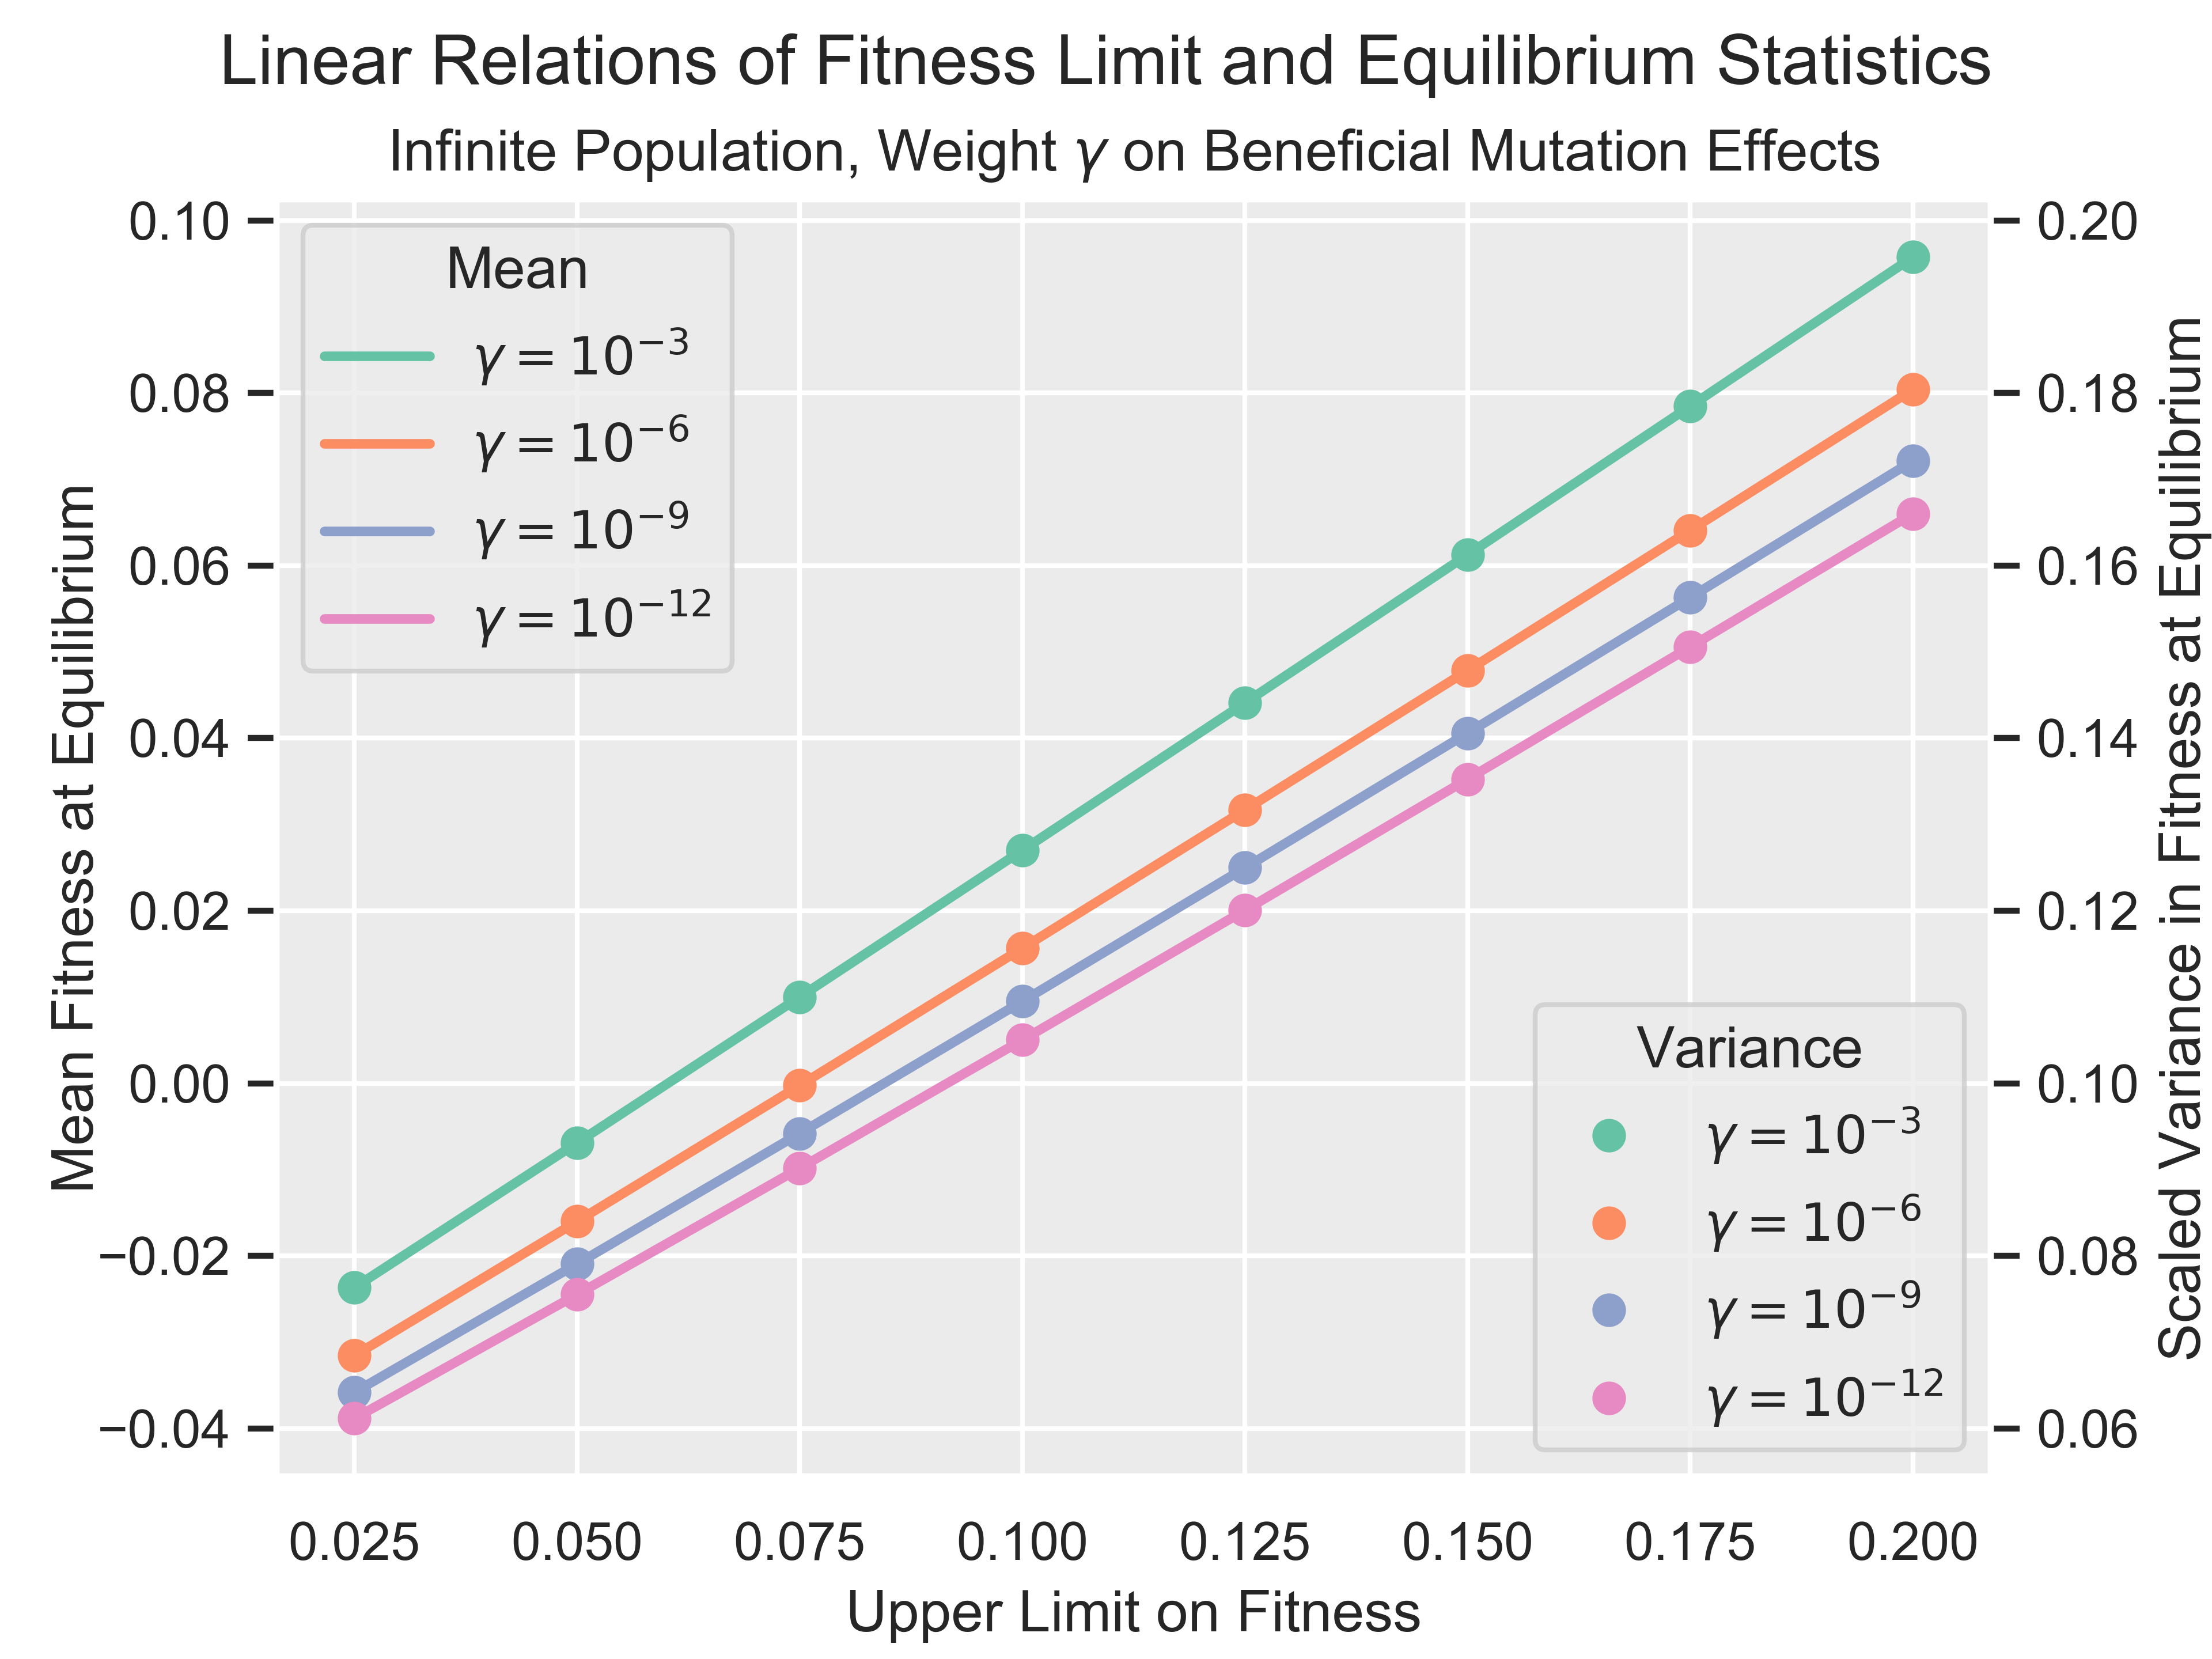

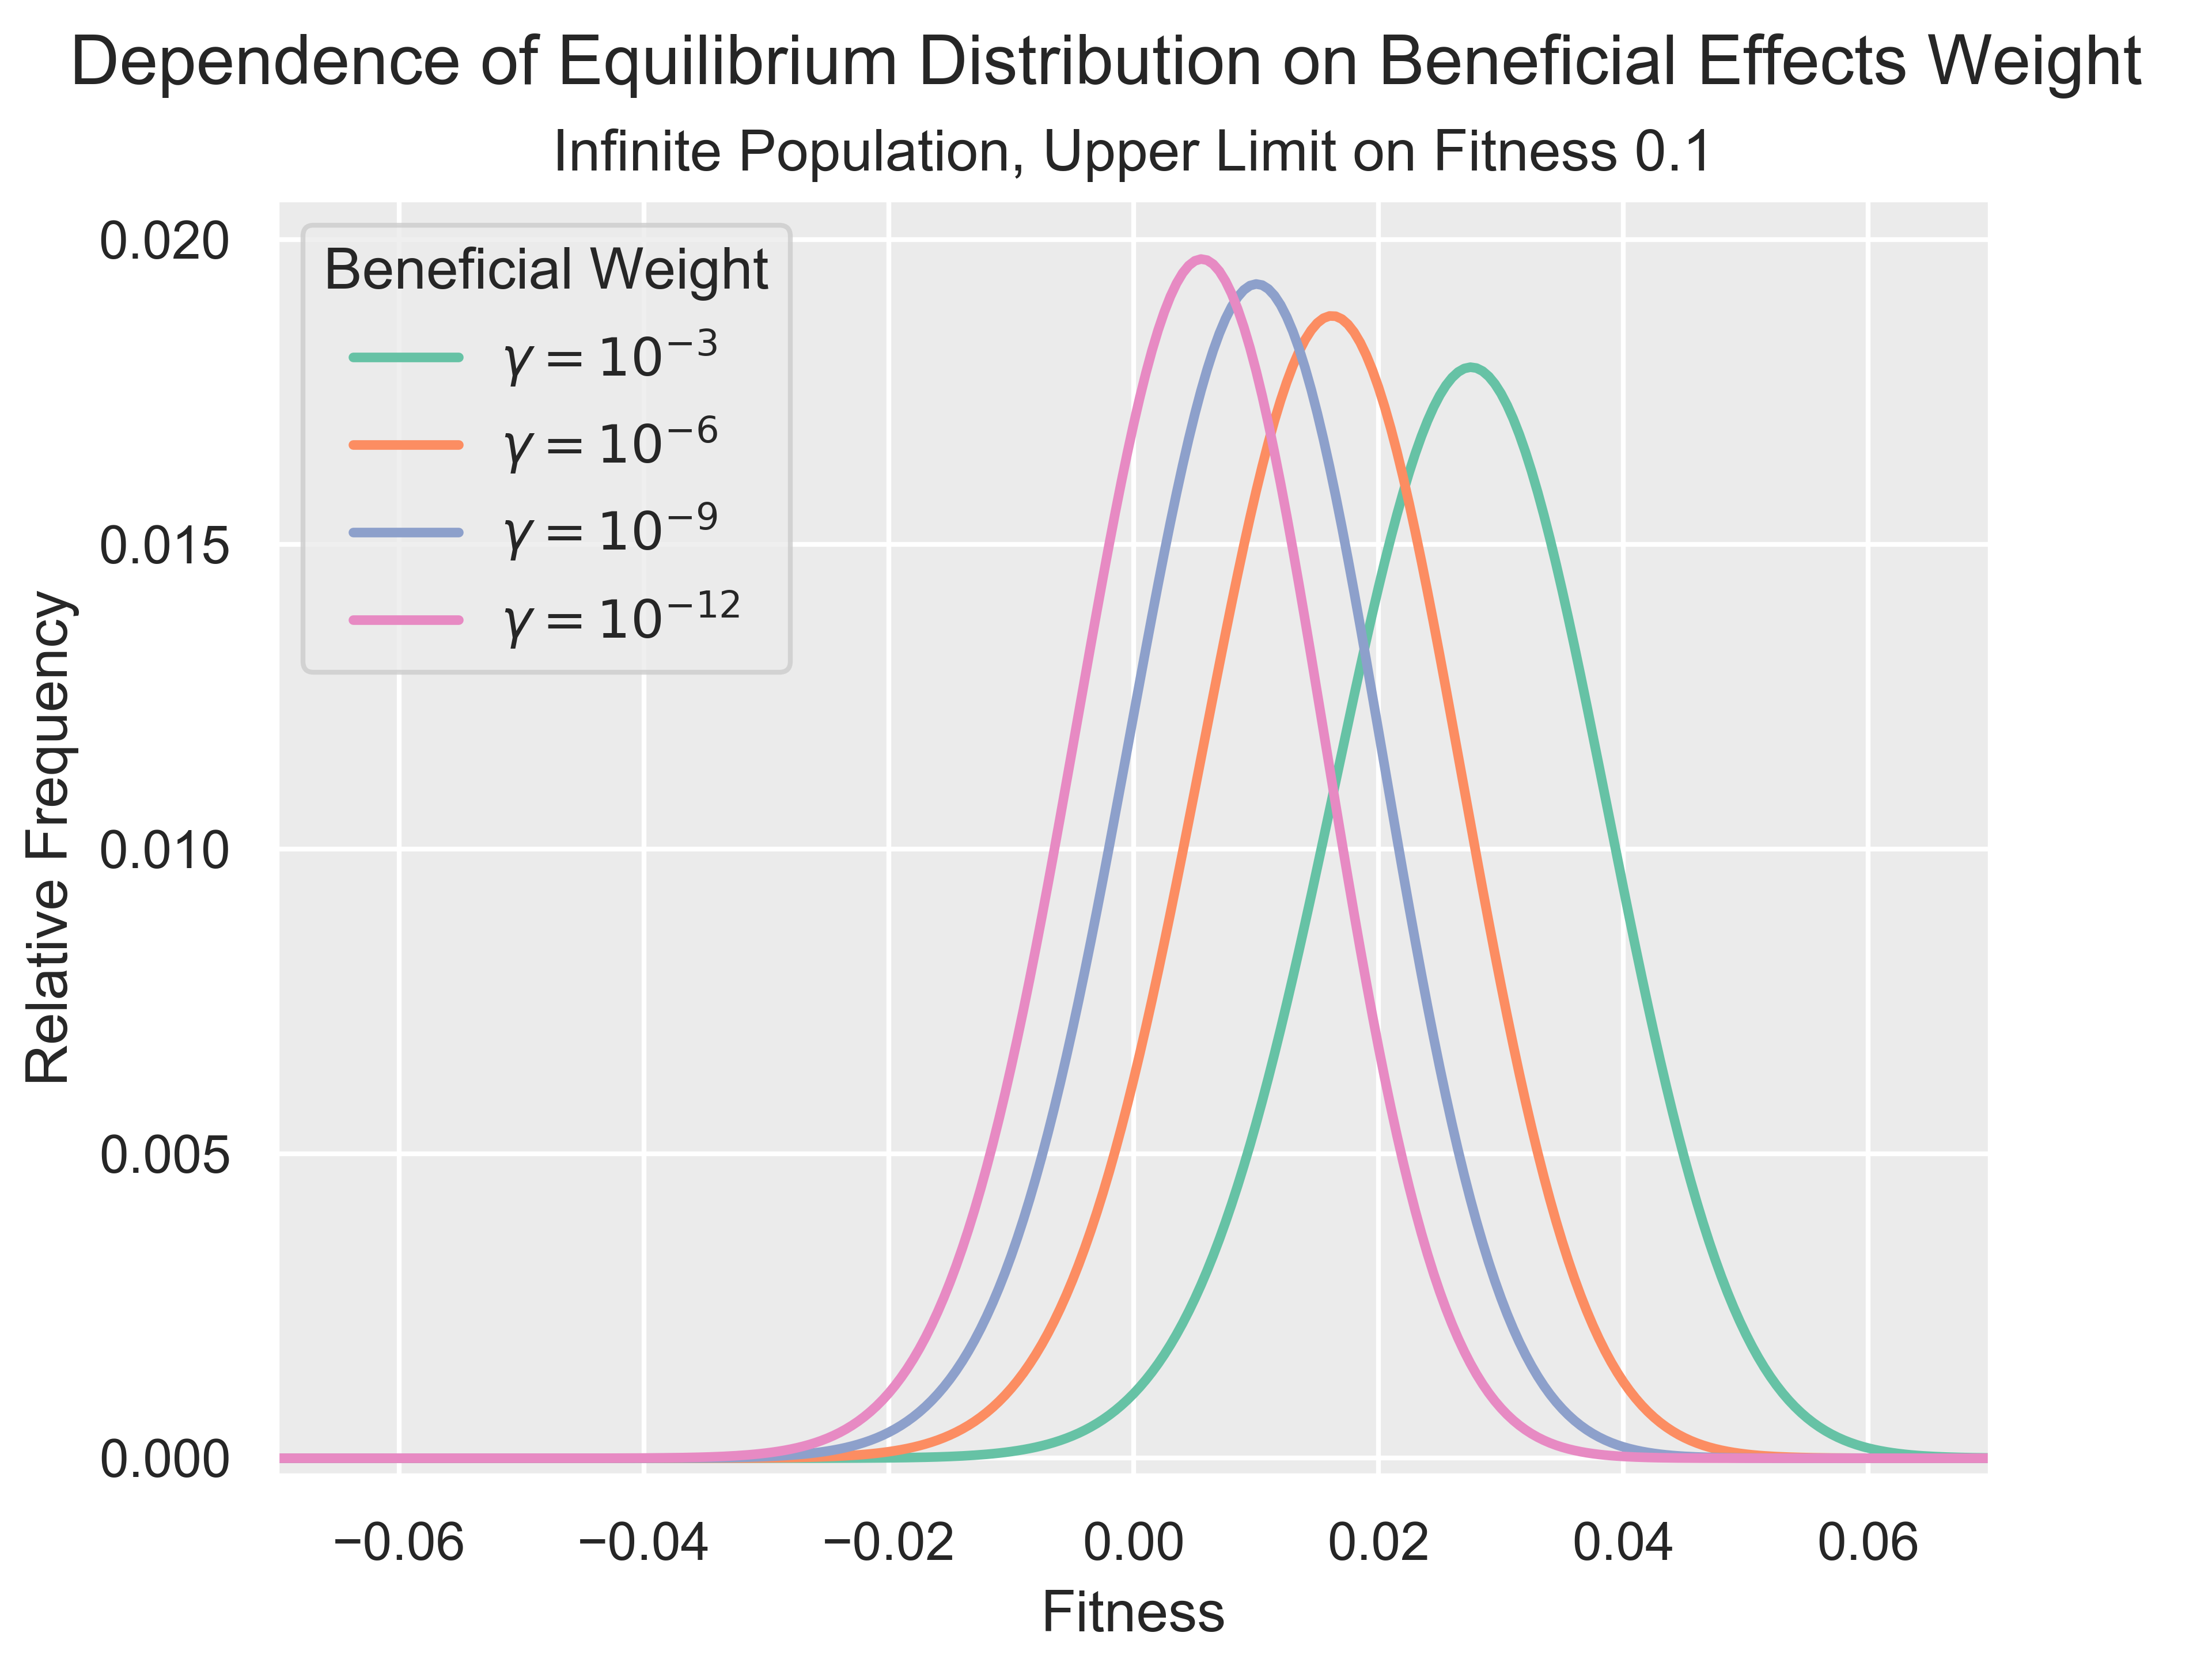

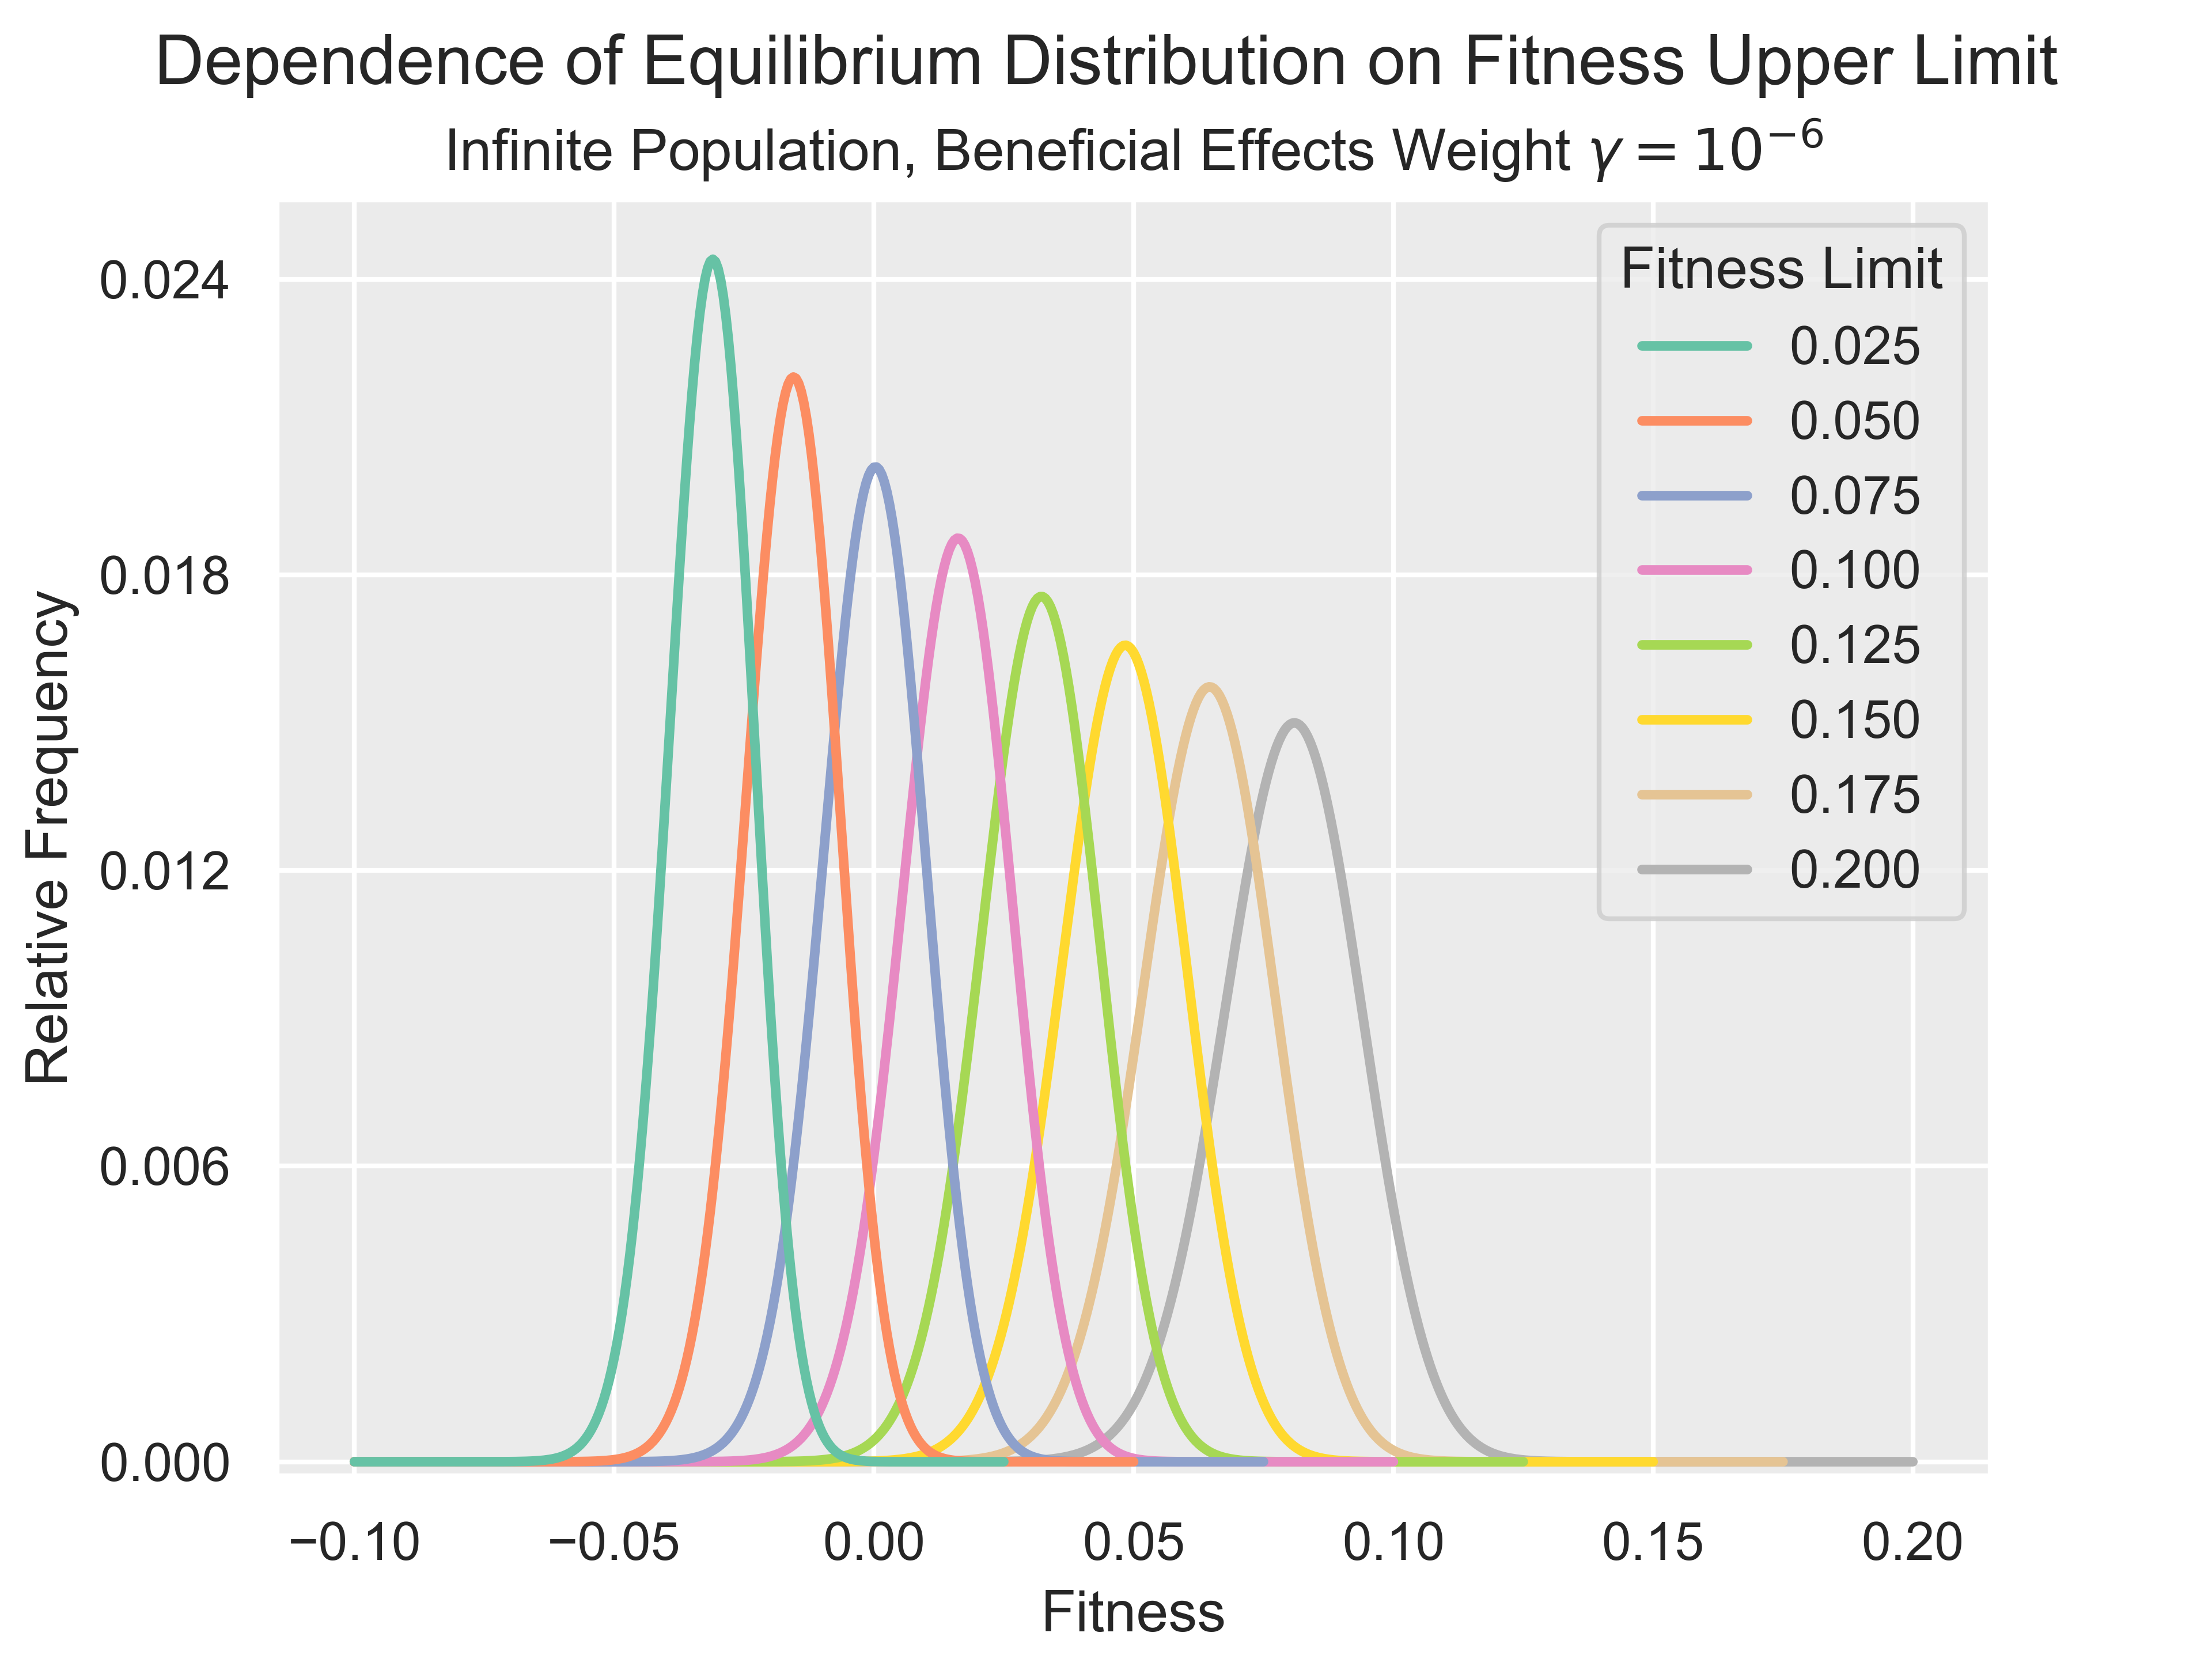

In [211]:
"""
Generate Figure 1 of the article.
"""
eq.plot_stats(
    'Linear Relations of Fitness Limit and Equilibrium Statistics',
    'Infinite Population, Weight $\gamma$ on Beneficial Mutation Effects')
eq.ax_mean.yaxis.set_label_coords(-0.1, 0.5)
eq.save_and_display(DIR + 'Fig1.png')

"""
Generate Figure 2 of the article.
"""
eq.plot_column(3)
eq.ax.set_xlim([-0.07, 0.07])
t = 'Dependence of Equilibrium Distribution on Beneficial Effects Weight'
eq.fig.suptitle(t)
eq.save_and_display(DIR + 'Fig2.png')

"""
Generate Figure 3 of the article.
"""
eq.plot_row(1)
t = 'Dependence of Equilibrium Distribution on Fitness Upper Limit'
eq.fig.suptitle(t)
eq.save_and_display(DIR + 'Fig3.png')

In [206]:
def regression_report(log_weights, fitness_limits):
    def print_results(regression, log_weight):
        print('Beneficial weight 10^{}'.format(log_weight))
        print('\tslope       :', regress.slope)
        print('\tintercept   :', regress.intercept)
        print('\tcorrelation :', regress.rvalue)

    print('Linear regression of mean on variance')
    for i, log_weight in enumerate(log_weights):
        regress = stats.linregress(eq.var[i], eq.mean[i])
        print_results(regress, log_weight)

    print('\nLinear regression of variance on max fitness')
    for i, log_weight in enumerate(log_weights):
        regress = stats.linregress(fitness_limits, eq.var[i])
        print_results(regress, log_weight)

regression_report(log_weights, eq.limits.astype(float))

Linear regression of mean on variance
Beneficial weight 10^-3
	slope       : 1019.1015858424463
	intercept   : -0.1000000000236546
	correlation : 1.0
Beneficial weight 10^-6
	slope       : 1017.0654166266083
	intercept   : -0.09999999999606801
	correlation : 0.9999999999999999
Beneficial weight 10^-9
	slope       : 1017.0633844482353
	intercept   : -0.09999999998492944
	correlation : 0.9999999999999998
Beneficial weight 10^-12
	slope       : 1017.0633822313107
	intercept   : -0.0999999999608083
	correlation : 1.0

Linear regression of variance on max fitness
Beneficial weight 10^-3
	slope       : 0.0006698581425665265
	intercept   : 5.784450057320426e-05
	correlation : 0.9999883243233322
Beneficial weight 10^-6
	slope       : 0.0006294379976519779
	intercept   : 5.108910439758114e-05
	correlation : 0.9999691024049323
Beneficial weight 10^-9
	slope       : 0.0006069860811202156
	intercept   : 4.7361266313341574e-05
	correlation : 0.999949725287991
Beneficial weight 10^-12
	slope       :

# Random finite -- MOVE

In [31]:
class FiniteSim(object):
    """
    Base class.
    
    Requires that `capacity' method be defined by subclass.
    """
    def __init__(self, rates, mutation_matrix, init_dist, steps_per_year=1,
                       max_size=1e9, init_size=None):
                       # init_mean=0.044, init_std=0.005):
        self.rates = rates
        self.n = len(rates.fitness)
        self.u = np.array(mutation_matrix.T)
        self.init_dist = init_dist
        self.steps_per_year = steps_per_year
        self.birth_rates = self.rates.birth / steps_per_year
        self.death_rate = self.rates.death / steps_per_year
        self.birthing = self.birth_rates * mutation_matrix
        self.max_size = max_size
        if init_size is None:
            init_size = max_size
        elif init_size > max_size:
            raise Exception('Initial pop size greater than max size')
        # self.init_mean = init_mean
        # self.init_std = init_std
        # p = normal_pdf(rates.fitness, init_mean, init_std)
        # p = (p / fsum(p)).astype(float)
        self.freqs = rand.multinomial(init_size, init_dist)
        self.n_years = 0
        self.results = np.empty((1, len(self.freqs)), dtype=int)
        self.results[self.n_years] = self.freqs


    def run(self, n_years):
        """
        SLOW!
        """
        self._allocate_memory(n_years)
        freqs = self.freqs
        for _ in range(n_years):
            for _ in range(self.steps_per_year):
                pop_size = np.sum(freqs)
                if pop_size == 0:
                    return
                expect_deaths = self.death_rate * pop_size
                #
                # Numbers of unmutated births are Poisson distributed.
                lambdas = self.birth_rates * freqs
                expect_births = fsum(lambdas)
                p = lambdas / expect_births
                #
                # Adjust expected numbers of births and deaths to keep
                # expected pop size from exceeding carrying capacity.
                expect_deaths, expect_births = \
                    self.capacity(pop_size, expect_deaths, expect_births)
                #
                # Numbers of deaths are binomially distributed.
                d = expect_deaths / pop_size
                n_deaths = [rand.binomial(n, d) for n in freqs]
                #
                # Numbers of unmutated births are Poisson distributed.
                total_births = stats.poisson.rvs(expect_births)
                n_births = rand.multinomial(total_births, p)
                #
                # Add numbers of mutated births to frequencies.
                for j in range(self.n):
                    if n_births[j] > 0:
                        freqs += rand.multinomial(n_births[j], self.u[j])
                #
                # Subtract numbers of deaths from frequencies.
                np.subtract(freqs, n_deaths, out=freqs)
            self.n_years += 1
            self.results[self.n_years] = freqs


    def __call__(self, n_years):
        """
        FAST!
        """
        self._allocate_memory(n_years)
        freqs = self.freqs
        for _ in range(n_years):
            for _ in range(self.steps_per_year):
                pop_size = np.sum(freqs)
                if pop_size == 0:
                    return
                expect_deaths = self.death_rate * pop_size
                #
                # Numbers of mutant births are Poisson distributed.
                lambdas = np.dot(self.birthing, freqs)
                expect_births = fsum(lambdas)
                p = lambdas / expect_births
                #
                # Adjust expected numbers of births and/or deaths to keep
                # expected pop size from exceeding carrying capacity.
                expect_deaths, expect_births = \
                    self.capacity(pop_size, expect_deaths, expect_births)
                #
                # Numbers of deaths are binomially distributed.
                d = expect_deaths / pop_size
                n_deaths = rand.binomial(freqs, d)
                #
                # Numbers of mutant births are Poisson distributed.
                total_births = stats.poisson.rvs(expect_births)
                n_mutants = rand.multinomial(total_births, p)
                #
                # Update the frequencies.
                np.add(freqs, n_mutants, out=freqs)
                np.subtract(freqs, n_deaths, out=freqs)
            self.n_years += 1
            self.results[self.n_years] = freqs

    def _allocate_memory(self, n):
        rows, cols = self.results.shape
        new = np.zeros((rows+n, cols), dtype=int)
        new[:rows] = self.results
        self.results = new

    def _excess(self, pop_size, expected_deaths, expected_births):
        expected_size = pop_size - expected_deaths + expected_births
        return max(0, expected_size - self.max_size)

    def __getitem__(self, which):
        return self.results[which]
    
    def __len__(self):
        return len(self.results)
    
class VariableBirthRates(FiniteSim):
    def capacity(self, pop_size, expected_deaths, expected_births):
        excess = self._excess(pop_size, expected_deaths, expected_births)
        return expected_deaths, max(0, expected_births - excess)

class VariableDeathRate(FiniteSim):
    def capacity(self, pop_size, expected_deaths, expected_births):
        """excess = self._excess(pop_size, expected_deaths, expected_births)
        return expected_deaths + excess, expected_births"""
        expected_deaths = max(expected_deaths, pop_size - self.max_size)
        return expected_deaths, expected_births
    
class LogisticBirthRates(FiniteSim):
    def capacity(self, pop_size, expected_deaths, expected_births):
        scale = max(0, 1 - (pop_size - expected_deaths) / self.max_size)
        return expected_deaths, scale * expected_births
        """scale = 1 - pop_size / self.max_size
        expected_births = expected_deaths + scale * (expected_births
                                                     - expected_deaths)
        return expected_deaths, expected_births"""

In [35]:
%%time

r = Rates(0.20, bin_width=0.0005)
p = binned_mixture(gamma_ccdf, len(r.effects), '1e-3', r.bin_width)
#comp_cdf = lambda x: 2 * normal_ccdf(x, 0, 0.001)
#p = binned_mixture(comp_cdf, len(r.effects), '0.5', r.bin_width)
p = p.astype(float)
u = Derivative.mutation_matrix(p)
eq_dist = Derivative(p, r).equilibrium()
init_dist = eq_dist
#init_dist = normal_pdf(r.fitness, 0.0, 0.012).astype(float)
#init_dist /= fsum(init_dist)
s = VariableDeathRate(r, u, init_dist, 8, max_size=1e11, init_size=None)

CPU times: user 636 ms, sys: 14.7 ms, total: 651 ms
Wall time: 321 ms


In [36]:
%%time

plt.close('all')
s(5000)

CPU times: user 1min 7s, sys: 3.35 s, total: 1min 10s
Wall time: 20.1 s


Slight difference appears at $K=10^{15}.$ Mean stays close to that of equilibrium with $K=10^{13},$ but there's considerable sloshing about of the population. Mean drops below that of equilibrium with $K=10^{12}$ (from 2.70 init to 2.58 at one time I looked at; but then I checked 10 thousand years later, and found 2.99 mean with low variance -- so the sloshing about is more pronounced). In a run with $K={11},$ the population nearly went extinct, but then recovered.

max year: 5000
Carrying capacity: 1.000000e+11
Init dist mean and var: 2.700174e-02 1.246213e-04
Init pop mean and var : 2.700176e-02 1.246210e-04
Final pop mean and var: 9.311401e-03 1.030429e-04
Final pop size        : 1.013853e+11


<IPython.core.display.Javascript object>


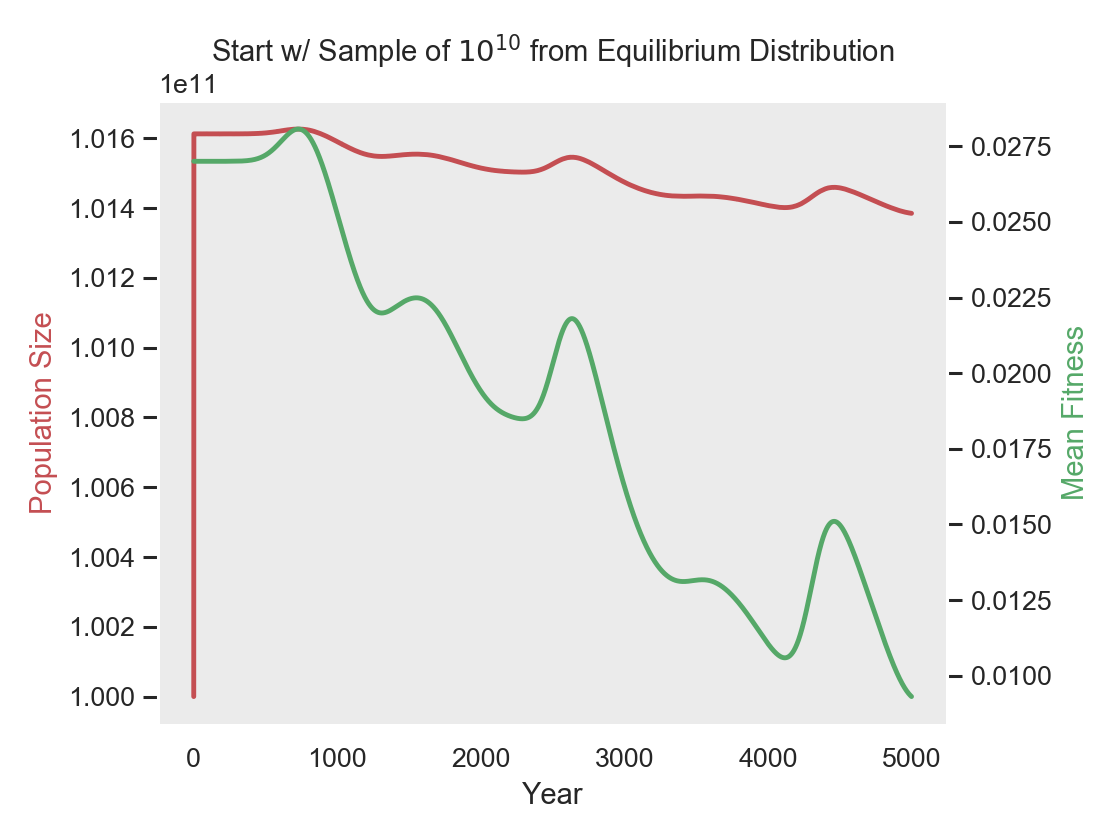

In [37]:
sizes = np.sum(s, axis=1)
n = len(sizes) - np.argmax(sizes[::-1] > 0) - 1
sizes = sizes[:n+1]
years = np.arange(n+1)
print('max year:', n)
print('Carrying capacity: {:e}'.format(s.max_size))
print('Init dist mean and var: {:e} {:e}'.format(*mean_var(s.init_dist,
                                                           r.fitness)))
print('Init pop mean and var : {:e} {:e}'.format(*mean_var(s[0],
                                                           r.fitness)))
print('Final pop mean and var: {:e} {:e}'.format(*mean_var(s[n],
                                                           r.fitness)))
print('Final pop size        : {:e}'.format(np.sum(s[n])))
plt.close()
fig, ax_size = plt.subplots()
ax_fit = ax_size.twinx()
ax_fit.grid(False)
ax_size.grid(False)
ax_size.plot(years, sizes, c='r')
ax_size.set_title('Start w/ Sample of $10^{10}$ from Equilibrium Distribution', pad=16)
ax_size.set_xlabel('Year')
ax_fit.set_ylabel('Mean Fitness', c='g')
ax_size.set_ylabel('Population Size', c='r')
m, v = mean_and_variance(r.fitness, s[:n+1] / sizes[:, None])
ax_fit.plot(years, m, c='g')
fig.tight_layout()
#plt.plot(np.arange(n+1), s[:n+1])

fig.savefig('carrying_1e10.png', format='png')

def solution(s, t):
    r = s.rates.fitness
    N0 = s[0]
    K = s.max_size * (N0 / fsum(N0))
    return (K * N0) / (N0 + (K - N0) * exp(-r * t))

<IPython.core.display.Javascript object>


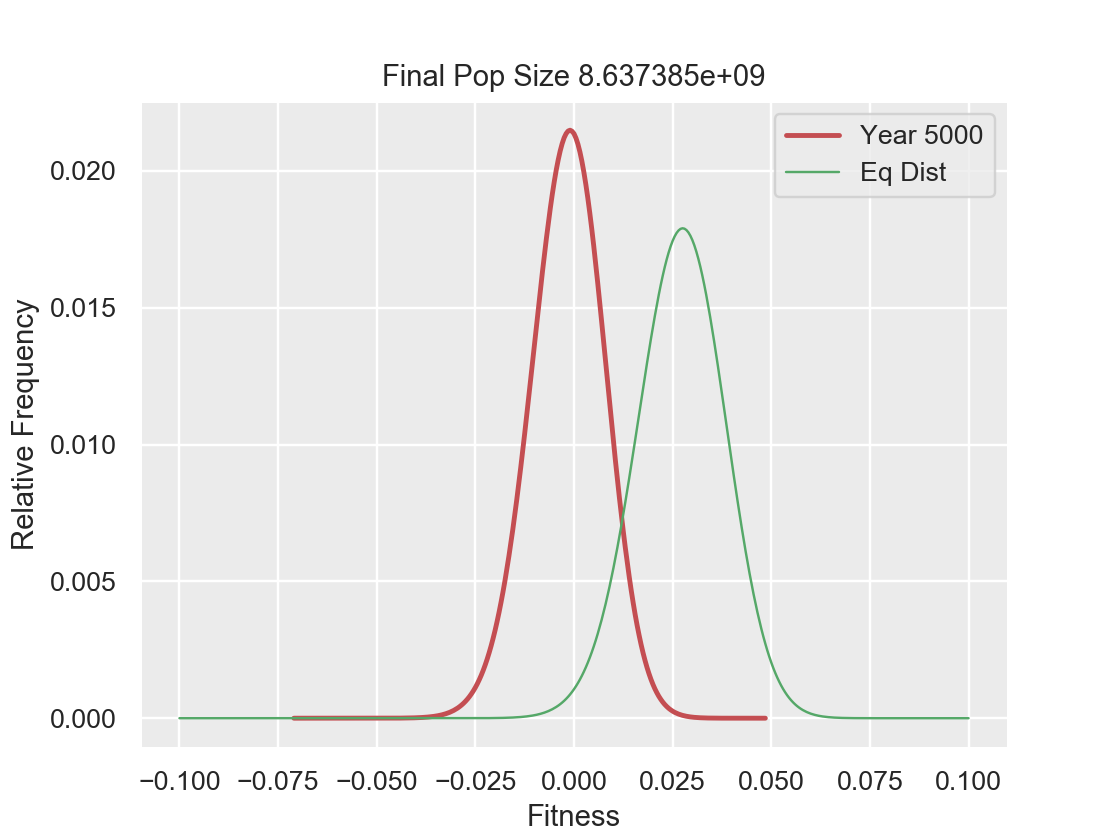

In [9]:
m = n
fig, ax = plt.subplots()
#ax.vlines(r.fitness, 0, init_dist, color='g', alpha=0.5, label='Eq Dist')
#ax.vlines(r.fitness, 0, s[m] / mp.fsum(s[m]), color='r', alpha=0.5, zorder=100,
#          label='Year {}'.format(m))
w = s[m] > 0
ax.plot(r.fitness[w], s[m, w] / mp.fsum(s[m]), color='r', zorder=100,
          label='Year {}'.format(m))
ax.plot(r.fitness, eq_dist, color='g', lw=1, label='Eq Dist', zorder=101)
ax.set_title('Final Pop Size {:e}'.format(sum(s[m])))
ax.set_ylabel('Relative Frequency')
ax.set_xlabel('Fitness')
ax.legend(loc='best')

In [11]:
sum(s.results[-1])

8637384639